In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import hdbscan
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

In [ ]:
import requests
import zipfile
import io 
import os

zip_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YcUk-ytgrPkmvZAh5bf7zA/Canada.zip'

canada_dir = "./Canada Data"
os.makedirs(canada_dir, exist_ok=True)

response = requests.get(zip_url)
response.raise_for_status()
with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
    list = []
    for canada_file in zip_file.namelist():
        if canada_file.endswith(".tif"):
            ext_path = zip_file.extract(canada_file, canada_dir)
            list.append(ext_path)
    return list
            #canada_file = os.path.join(canada_dir, canada_file)
            #print(f"Canadian Map: {canada_file}")

In [3]:
import os 

file_path = "C:/Users/LAPTOP/Downloads/Canada"
for file in os.listdir(file_path):
    if file.endswith(".tif"):
        file = os.path.join(file_path, file)
        print("Canadian Map: ", file)
    

Canadian Map:  C:/Users/LAPTOP/Downloads/Canada\Canada.tif


In [31]:
def canadian_proximity_cluster(data, title="The Proximity of Art&Cultural Buildings in Canada"):
    geodata = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data["Longitude"], data["Latitude"]), crs="EPSG:4326")
    geodata = geodata.to_crs(epsg=3857)
    figure, axis = plt.subplots(figsize=(15,10))
    noise = geodata[geodata["Cluster"] == -1]
    not_noise = geodata[geodata["Cluster"] != -1]

    noise.plot(ax=axis, color="k", markersize= 25, ec="r", alpha=1, label="Noise")
    not_noise.plot(ax=axis, column="Cluster", cmap="tab10", alpha=0.6, markersize=30, ec="k", legend=False)
    ctx.add_basemap(axis, source='Canada Data/Canada.tif', zoom=4)
    
    plt.title(title)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    axis.set_xticks([])
    axis.set_yticks([])
    plt.tight_layout()

    plt.show()

In [5]:
path = "C:/Users/LAPTOP/Downloads/ODCAF_v1.0/ODCAF_v1.0.csv"
canned = pd.read_csv(path, encoding = "ISO-8859-1")
canned

,Index,Facility_Name,Source_Facility_Type,ODCAF_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
0,1,#Hashtag Gallery,..,gallery,toronto,..,801,dundas st w,M6J 1V2,toronto,on,801 dundas st w,Toronto,3520005,35,43.65169472,-79.40803272
1,2,'Ksan Historical Village & Museum,historic site-building or park,museum,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,3,'School Days' Museum,community/regional museum,museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
3,4,10 Austin Street,built heritage properties,heritage or historic site,moncton,..,10,austin st,E1C 1Z6,moncton,nb,10 austin st,Moncton,1307022,13,46.09247776,-64.78022946
4,5,10 Gates Dancing Inc.,arts,miscellaneous,ottawa,..,..,..,..,ottawa,on,..,Ottawa,3506008,35,45.40856224,-75.71536766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,9792,Zurich Libary,library,library or archives,huron county,..,10,goshen st n,N0M 2T0,huron county,on,"10 goshen st n, zurich, on n0m 2t0",Bluewater,3540010,35,43.4213556,-81.624695
7968,9797,Craigdarroch Castle,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.42241956,-123.3435527
7969,9798,..,museums and galleries,museum,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.4260053,-123.3691883
7970,9799,..,performance space - indoor venue,theatre/performance and concert hall,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.43154807,-123.3590685


In [6]:
canned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7972 entries, 0 to 7971
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Index                  7972 non-null   int64 
 1   Facility_Name          7972 non-null   object
 2   Source_Facility_Type   7972 non-null   object
 3   ODCAF_Facility_Type    7972 non-null   object
 4   Provider               7972 non-null   object
 5   Unit                   7972 non-null   object
 6   Street_No              7972 non-null   object
 7   Street_Name            7972 non-null   object
 8   Postal_Code            7972 non-null   object
 9   City                   7972 non-null   object
 10  Prov_Terr              7972 non-null   object
 11  Source_Format_Address  7972 non-null   object
 12  CSD_Name               7972 non-null   object
 13  CSDUID                 7972 non-null   object
 14  PRUID                  7972 non-null   object
 15  Latitude             

In [7]:
canned["ODCAF_Facility_Type"].value_counts()

ODCAF_Facility_Type
library or archives                     3013
museum                                  1938
gallery                                  810
heritage or historic site                620
theatre/performance and concert hall     583
festival site                            346
miscellaneous                            343
art or cultural centre                   225
artist                                    94
Name: count, dtype: int64

In [8]:
canned_museum = canned[canned.ODCAF_Facility_Type == "museum"]
canned_museum.dropna
can = canned_museum.drop(["Index", "ODCAF_Facility_Type"],axis=1)
can

,Facility_Name,Source_Facility_Type,Provider,Unit,Street_No,Street_Name,Postal_Code,City,Prov_Terr,Source_Format_Address,CSD_Name,CSDUID,PRUID,Latitude,Longitude
1,'Ksan Historical Village & Museum,historic site-building or park,canadian museums association,..,1500,62 hwy,V0J 1Y0,hazelton,bc,1500 hwy 62 hazelton british columbia v0j 1y0 ...,Hazelton,5949022,59,55.2645508,-127.6428124
2,'School Days' Museum,community/regional museum,canadian museums association,..,427,queen st,E3B 5R6,fredericton,nb,427 queen st fredericton new brunswick e3b 5r6...,Fredericton,1310032,13,45.963283,-66.6419017
8,12 Service Battalion Museum,military museum or fort,canadian museums association,..,5500,no 4 rd,V6X 3L5,richmond,bc,5500 no. 4 rd the sherman armoury richmond bri...,Richmond,5915015,59,49.1763542,-123.112783
13,15th Field Artillery Regiment Museum And Archives,museum/gallery,vancouver,..,2025,11th av w,V6J 2C7,vancouver,bc,2025 w 11th av vancouver bc v6j 2c7,Vancouver,5915022,59,49.261938,-123.151123
15,17 Wing Heritage Collection,aeronautics and space museum transportation mu...,canadian museums association,..,..,..,R3J 3Y5,winnipeg,mb,air heritage park air force way winnipeg manit...,Winnipeg,4611040,46,49.88955855,-97.23574396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7940,York Region District School Board Museum & Arc...,library and/or archives community/regional museum,canadian museums association,..,21,renfrew dr,L3R 8H3,markham,on,21 renfrew dr markham ontario l3r 8h3 canada,Markham,3519036,35,43.857692,-79.3619396
7954,Youthlink Calgary-The Calgary Police Interpret...,community/regional museum exhibition or cultur...,canadian museums association,..,5111,47th street ne,T3J 3R2,calgary,ab,5111-47th street ne lc594 calgary alberta t3j ...,Calgary,4806016,48,..,..
7958,Yukon Beringia Interpretive Centre,human history-archaelogy-anthropology or ethno...,canadian museums association,..,1423,alaska hwy,Y1A 2C6,whitehorse,yt,kilometre 1423 (mile 886) alaska hwy po box 27...,Whitehorse,6001009,60,..,..
7968,Craigdarroch Castle,museums and galleries,victoria,..,..,..,..,victoria,bc,..,Victoria,5917034,59,48.42241956,-123.3435527


In [9]:
X = can[["Latitude", "Longitude"]]
X = X[X.Latitude != ".."]
X = X[X.Longitude != ".."] 
X[['Latitude','Longitude']] = X[['Latitude','Longitude']].astype('float')
X.dtypes

Latitude     float64
Longitude    float64
dtype: object

In [10]:
scaled_coor = X.copy()
scaled_coor["Latitude"] = 2*scaled_coor["Latitude"]
scaled_coor

,Latitude,Longitude
1,110.529102,-127.642812
2,91.926566,-66.641902
8,98.352708,-123.112783
13,98.523876,-123.151123
15,99.779117,-97.235744
...,...,...
7934,86.366180,-79.224564
7936,87.380043,-79.476208
7940,87.715384,-79.361940
7968,96.844839,-123.343553


In [11]:
min_samples=3
eps=1.0
metric='euclidean' 

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(scaled_coor)

In [38]:
X["Cluster"] = dbscan.fit_predict(scaled_coor)
db_X = X

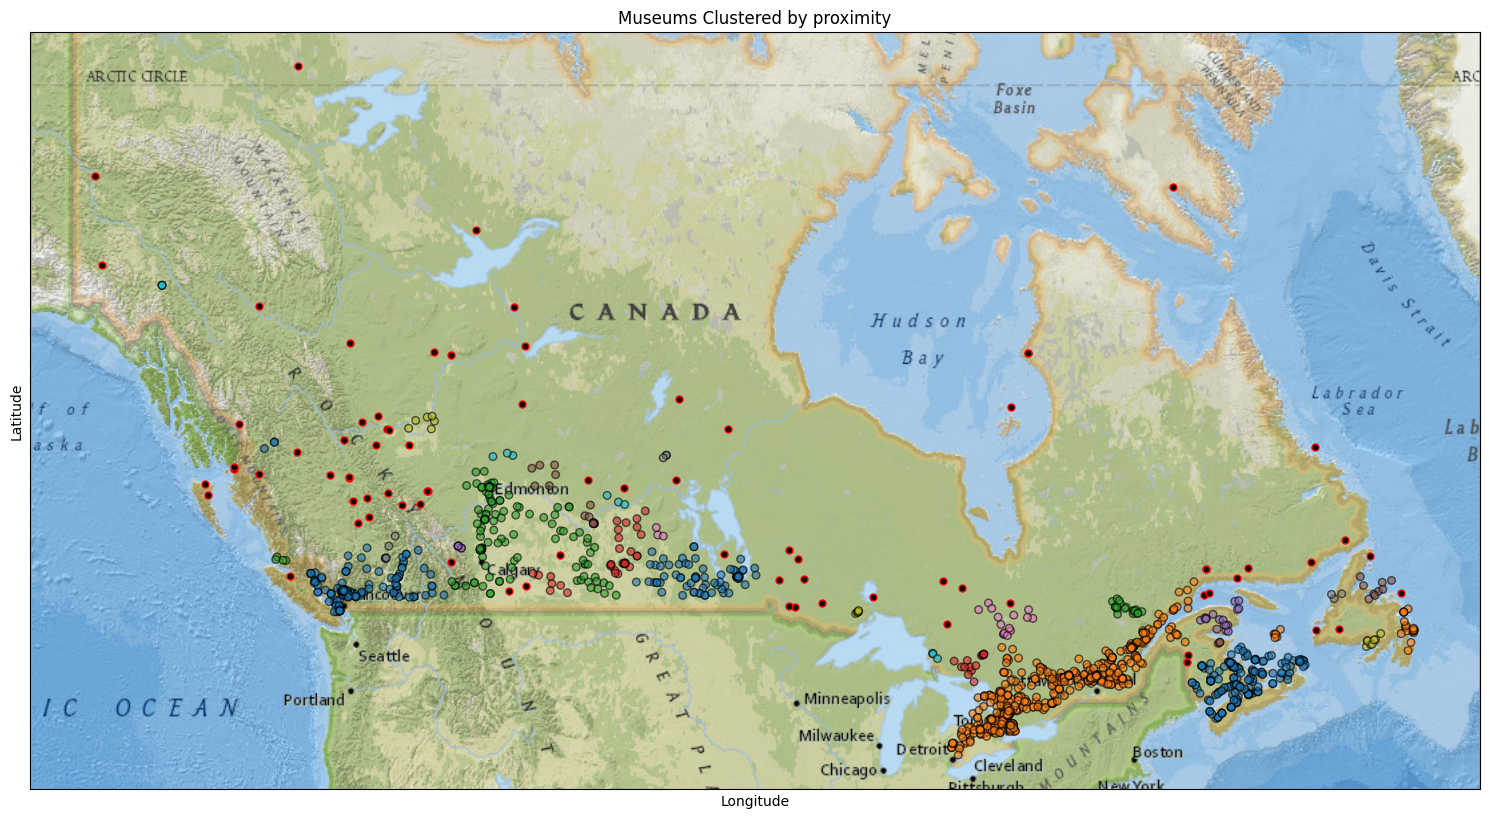

In [39]:
canadian_proximity_cluster(db_X, title="Museums Clustered by proximity")

In [56]:
min_samples = None
min_cluster_size = 3
hdb = hdbscan.HDBSCAN(min_samples=min_samples, min_cluster_size=min_cluster_size, metric=metric)

In [57]:
X["Cluster"] = hdb.fit_predict(scaled_coor)
X["Cluster"].value_counts()
hdb_X = X

C:\Users\LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


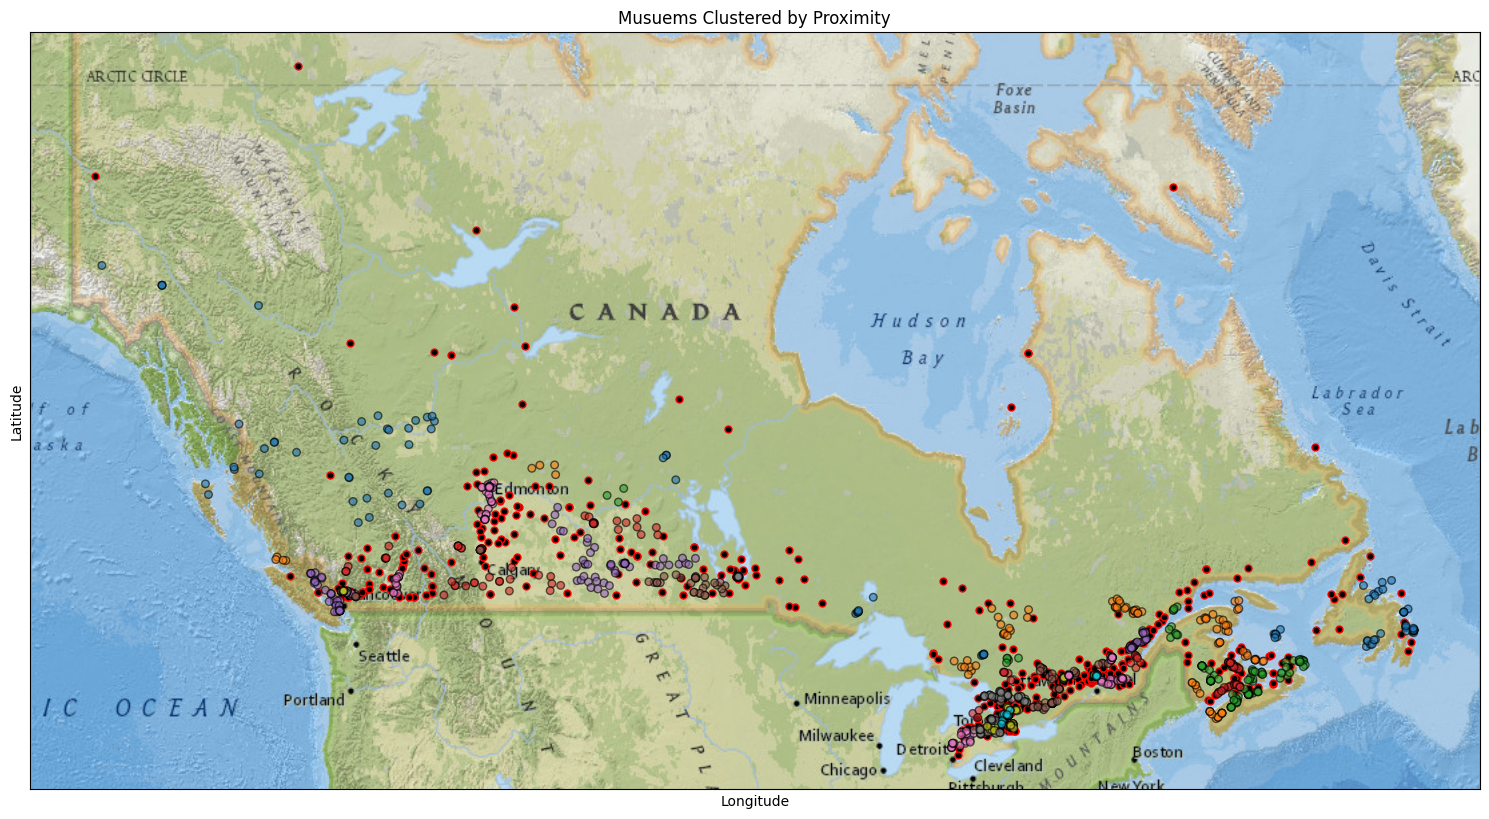

In [58]:
canadian_proximity_cluster(hdb_X, title="Musuems Clustered by Proximity")